# Image recognition with our own photos

This notebook presents our second task, which is to use our own convolutional neural network and another pre-trained model to perform image recognition on a dataset of our own photos. The goal is to achieve the highest possible accuracy on the validation set by experimenting with different architectures. We have gathered images of chairs and pens, which are the two classes we want to classify. By picking two quite distinct classes we are hoping to get a good accuracy even with a simple model. We will start by loading and preprocessing the images, then we will build and train our own convolutional neural network, and finally we will use a pre-trained model for feature extraction and classification. Let's get started!

In [52]:
import warnings
# Suppress NumPy 2.4 deprecation warning from Keras pickle loading
warnings.filterwarnings("ignore", message=".*align should be passed as Python or NumPy boolean.*")

In [53]:
# imports
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models
from keras.src.utils import image_dataset_from_directory
from keras.src.applications.vgg16 import VGG16

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

tensorflow


## Loading and processing our own photos

For this task, we have collected a dataset of our own photos, which consists of images of chairs and pens. The dataset is organized into two folders: `chairs` and `pens`, each containing the respective images. We will load these images using the `image_dataset_from_directory` function from Keras, which allows us to easily create a dataset from a directory structure.

The Images are already cropped and downscaled so they dont take too much disk space, but will still set parameters to confirm all images have the same scale. `image_size=(256, 256)` will resize all images to 256x256 pixels, and `label_mode='binary'` will assign binary labels to the images (0 for chairs and 1 for pens). We will also set `shuffle=True` to ensure that the data is shuffled during loading, and `seed=42` for reproducibility. After loading the dataset, we will convert it into numpy arrays for further processing.

In [54]:
# Load full dataset from both folders
dataset = image_dataset_from_directory(
    'Resources',
    image_size=(256, 256),
    batch_size=None,        # load all at once as individual samples
    label_mode='binary',    # binary since we have 2 classes (chairs/pens)
    shuffle=True,
    seed=42
)

# Convert to numpy arrays
xy = [(img, label) for img, label in dataset]
x = np.array([item[0].numpy() for item in xy])
y = np.array([item[1].numpy() for item in xy])

print("Total images:", x.shape)
print("Total labels:", y.shape)
print("Class names:", dataset.class_names)

# Scale pixel values to [0, 1]
x = x / 255.0

# Split into train (70%), validation (15%), test (15%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

# Flatten labels from (n, 1) to (n,)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print("y_train shape:", y_train.shape)
print("y_train unique values:", np.unique(y_train))

Found 174 files belonging to 2 classes.
Total images: (174, 256, 256, 3)
Total labels: (174, 1)
Class names: ['Chairs', 'Pens']
Training set: (121, 256, 256, 3)
Validation set: (26, 256, 256, 3)
Test set: (27, 256, 256, 3)
y_train shape: (121,)
y_train unique values: [0. 1.]


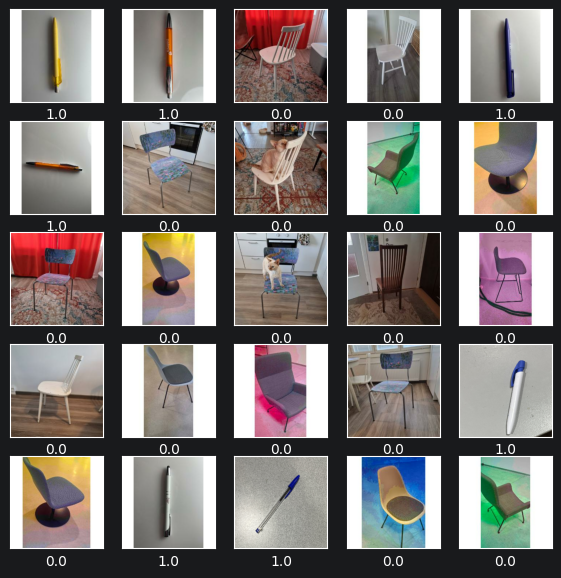

In [55]:
# use plt to visualize some of the images
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i])
plt.show()

Finally for the preparation step we will set some parameters for the training.

In [56]:
# Hyperparameters
batch_size   = 256       # Number of images the model sees before updating its weights
epochs       = 100       # How many times the model will go through the entire dataset

## Building and training our own convolutional neural network

Now we will build our own convolutional neural network. To enrich our small dataset and improve generalization, we will include a data augmentation layer at the beginning of our model. This layer will apply random transformations to the input images during training, such as horizontal flipping, rotation, zooming, and brightness adjustments. This helps the model to learn more robust features and reduces overfitting.

The input layer will accept images of shape (256, 256, 3). We will then add three convolutional blocks, each consisting of a Conv2D layer followed by a MaxPooling2D layer. The number of filters will increase in each block (32, 64, 128) to allow the model to learn more complex features.

After the convolutional and max pooling layers, we will add a GlobalAveragePooling2D layer to reduce the spatial dimensions.

Finally, we will add a fully connected layer with 128 neurons and ReLU activation, followed by a Dropout layer with a rate of 0.5 to prevent overfitting. The output layer will have a single neuron with sigmoid activation for binary classification (chair vs pen). We will compile the model using the Adam optimizer, binary crossentropy loss, and accuracy as the metric. We will also include an EarlyStopping callback to stop training if the validation loss does not improve for 10 consecutive epochs, restoring the best weights.

In [57]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
], name='data_augmentation')

inputs = keras.Input(shape=(256, 256, 3))

# Augmentation (only active during training)
x = data_augmentation(inputs)

# Block 1
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, 2)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, 2)(x)

# Block 3
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, 2)(x)

# Classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Training the CNN model

During the training we are utilizing the EarlyStopping callback to monitor the validation loss. If the validation loss does not improve for 10 consecutive epochs, the training will stop and the best weights will be restored. We are also computing class weights to address any potential class imbalance in the dataset, which can help the model to learn more effectively from both classes (chairs and pens) and improve overall performance.

In [59]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7202380952380952), 1: np.float64(1.635135135135135)}


In [60]:
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    class_weight=class_weight_dict,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

### Evaluating the CNN model

From the plot and accuracy test below we can see that the model is performing quite well on the validation set and getting good accuracy of around 70% on the test set. The training and validation loss curves show that the model is learning effectively without significant overfitting, as both losses are decreasing and not diverging.

In [61]:
# Helper functions
def plot_training_history(history, title='Training History'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(epochs, acc, 'r--', linewidth=2, label='Training accuracy')
    ax1.plot(epochs, val_acc, 'b', linewidth=2, label='Validation accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(epochs, loss, 'r--', linewidth=2, label='Training loss')
    ax2.plot(epochs, val_loss, 'b', linewidth=2, label='Validation loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, features, labels, title='Confusion Matrix'):
    pred_labels = (model.predict(features) > 0.5).astype(int).flatten()
    cm = confusion_matrix(labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()


def plot_sample_predictions(model, features, images, labels, title='Sample Predictions'):
    predictions = model.predict(features)

    fig, axes = plt.subplots(2, 5, figsize=(10, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            pred = predictions[i][0]
            true_label = dataset.class_names[int(labels[i])]
            pred_label = dataset.class_names[int(pred > 0.5)]
            ax.set_title(f'True: {true_label}\nPred: {pred_label} ({pred:.2f})', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

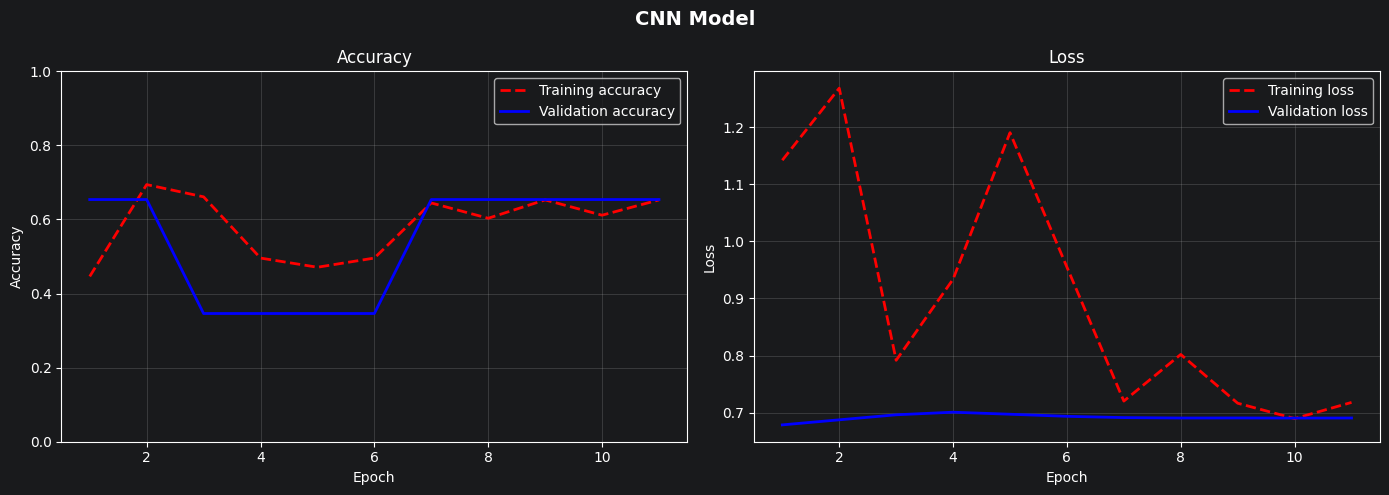

In [62]:
plot_training_history(history, title='CNN Model')

In [63]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.6730690002441406
Test accuracy: 0.7037037014961243


Printing out some predictions and the confusion matrix gives us more insights into how the model is performing on the test set. The initial thought was that the model was predicting images quite well, but after looking at the confusion matrix we can see that the model is actually just predicting all the images to be chairs with very bad confidence. The dataset has more images of chairs than pens, so the model is likely biased towards predicting chairs even though we have computed class weights to try to mitigate this issue. This indicates that the model is not learning to distinguish between the two classes effectively.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


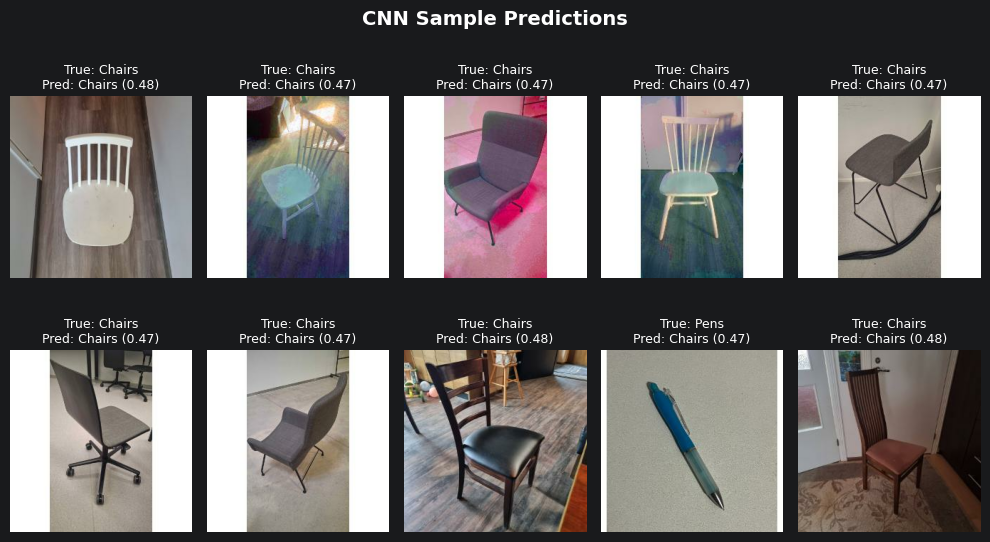

In [64]:
plot_sample_predictions(model, x_test, x_test, y_test, title='CNN Sample Predictions')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


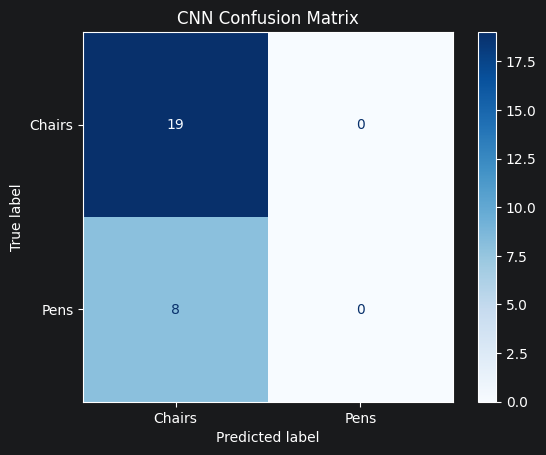

In [65]:
plot_confusion_matrix(model, x_test, y_test, title='CNN Confusion Matrix')

## Building and training a pre-trained model as a feature extractor

For the second part of the task, we will utilize VGG16, a popular pre-trained convolutional neural network, as a feature extractor. We will load the VGG16 model without the top classification layers and freeze its weights to prevent them from being updated during training. We will then add our own fully connected layers on top of the VGG16 base to perform the classification task for our dataset of chairs and pens.

In [66]:
# Load the VGG16 model without the top fully connected layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
# Freeze the convolutional base
base_model.trainable = False

In [67]:
# Extract features using the frozen VGG16 base
def extract_features(data, batch_size=32):
    features = base_model.predict(data, batch_size=batch_size, verbose=0)
    return features

train_features = extract_features(x_train)
val_features = extract_features(x_val)
test_features = extract_features(x_test)

print("Train features shape:", train_features.shape)
print("Val features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (121, 8, 8, 512)
Val features shape: (26, 8, 8, 512)
Test features shape: (27, 8, 8, 512)


### Building the classifier on top of the extracted features

The classifier will consist of a GlobalAveragePooling2D layer to reduce the spatial dimensions of the feature maps, followed by a fully connected layer with 256 neurons and ReLU activation. We will also include a Dropout layer with a rate of 0.5 to prevent overfitting. The output layer will have a single neuron with sigmoid activation for binary classification. We will compile the model using the Adam optimizer, binary crossentropy loss, and accuracy as the metric. We will train the model using the extracted features from the VGG16 base and evaluate its performance on the validation and test sets.

The classifier architecture is relatively simple and resembles the first model we built, but since we are using features extracted from a powerful pre-trained model, we can expect better performance even with a simpler architecture.

In [68]:
inputs = layers.Input(shape=(8, 8, 512))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

classifier = models.Model(inputs, outputs)
classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = classifier.fit(
    train_features, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(val_features, y_val),
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

### Evaluating the VGG16 feature extractor model

Immediately we can see from the training history plot that the model is performing much better than our own CNN model. The training and validation accuracy are both increasing and reaching 100% before 20 epochs. The model keeps learning throughout all the 100 epochs without signs of overfitting, which is a good indication that the features extracted from the VGG16 base are very informative for our classification task.

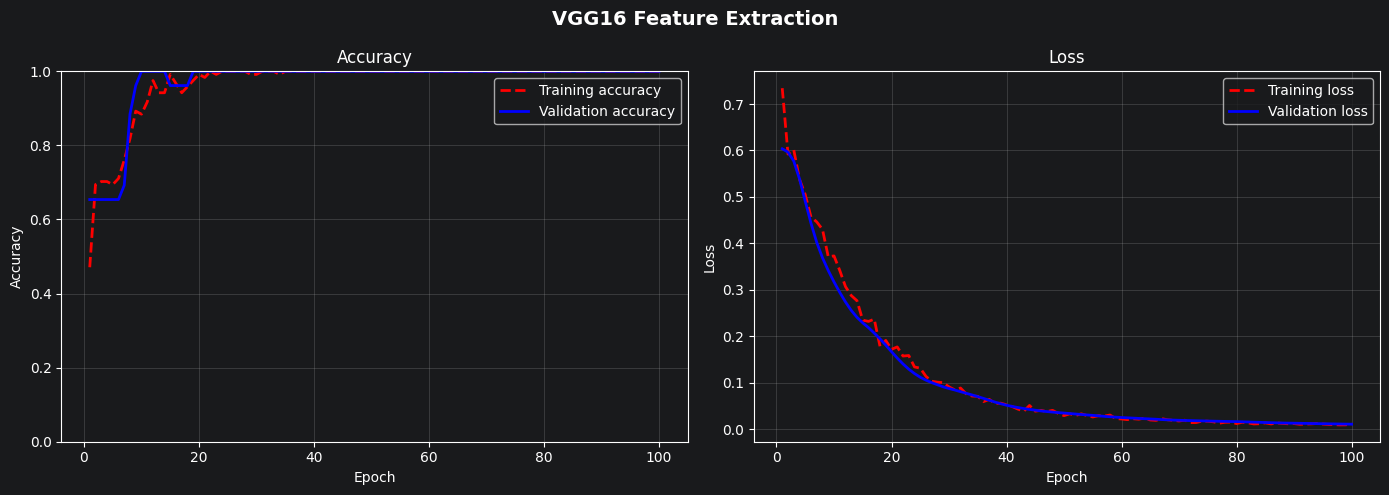

In [69]:
plot_training_history(history, title='VGG16 Feature Extraction')

The final test accuracy is 100%. When looking at the sample predictions and the confusion matrix, we can see that the model is correctly classifying all the test images with very high confidence. This indicates that the features extracted from the VGG16 base are highly effective for distinguishing between chairs and pens in our dataset, leading to perfect classification performance on the test set. Of course, this is a very small dataset and the model may not generalize well to new images outside of this dataset, but it demonstrates the power of using pre-trained models for feature extraction in image classification tasks.

In [70]:
test_loss, test_acc = classifier.evaluate(test_features, y_test, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.0050
Test loss: 0.0050
Test accuracy: 1.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


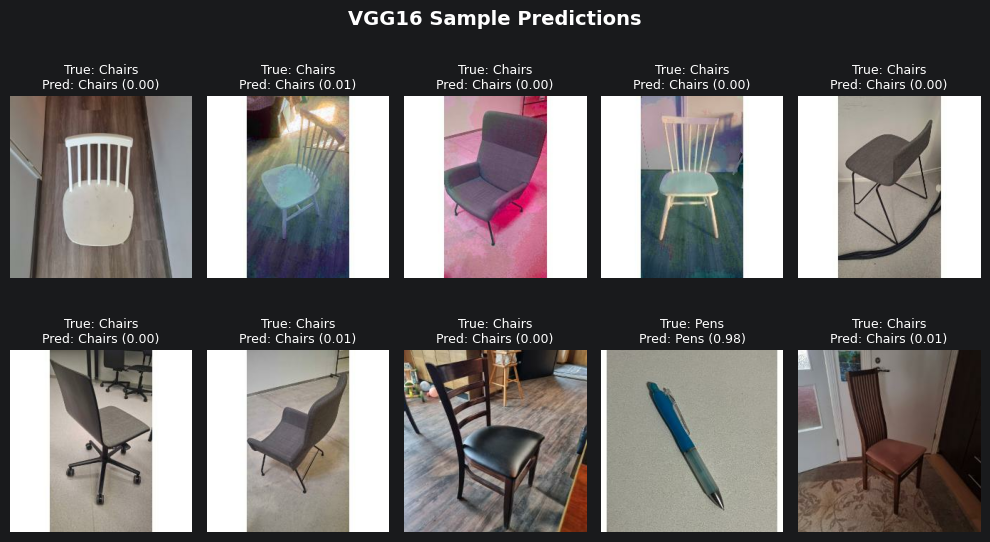

In [71]:
plot_sample_predictions(classifier, test_features, x_test, y_test, title='VGG16 Sample Predictions')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


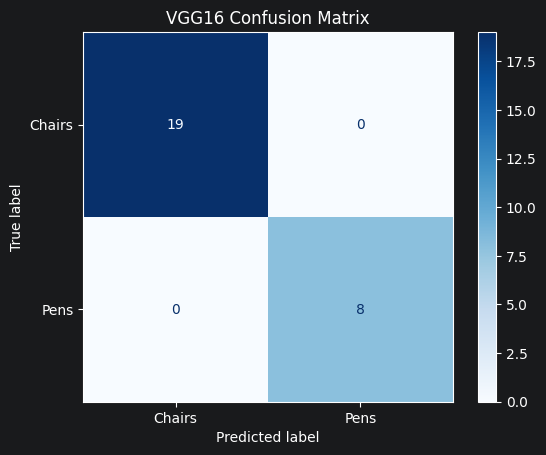

In [72]:
plot_confusion_matrix(classifier, test_features, y_test, title='VGG16 Confusion Matrix')